# What a hidden-state score measures after eight traces

**Workshop analysis of prompt-level selective prediction and trace-level
verification.**

This notebook studies three checkpoints on all 500 MATH-500 prompts. Each
checkpoint generates eight reasoning traces per prompt. Two checkpoints are
reasoning-distilled; Qwen2.5-7B-Instruct is not. The notebook reads committed
result files and does not run a model or fit a new readout. Notebook
[17](17_rmd_experiment_ledger.ipynb) contains the complete evidence ledger, and
`EXPERIMENT_LOG.md` records the protocols and decision rules.

---

## Main conclusion

A hidden-state RMD feature improves prompt-level selective prediction after
eight samples, beyond a baseline based on output statistics and
self-consistency. A high pooled trace AUROC does not establish that the same
feature identifies the correct trace among samples from one prompt.

The fixed eight-sample evaluation gives three results:

1. **Prompt-level selective prediction improves.** Adding the RMD feature to
   the target-only baseline changes AURC by **-0.0520 / -0.0284 / -0.0469**.
   Lower AURC is better, and all three fixed-pipeline 95% intervals exclude
   zero. The feature uses hidden states from the existing eight traces and
   requires no additional generations.

2. **Pooled trace discrimination does not imply sibling verification.** A
   supervised last-token probe reaches pooled trace AUROC **0.90 / 0.91 /
   0.90**, but macro within-prompt AUROC is **0.64 / 0.58 / 0.72**. Length also
   loses substantial discrimination after conditioning on prompt identity.

3. **Peer-model agreement is a competitive paid baseline.** At one additional
   peer generation, the six target-peer comparisons yield four ties, one RMD
   win, and one peer win after Holm correction. No peer condition has the same
   generation cost as RMD, which uses zero additional generations.

The present evidence covers one dataset, one sampling protocol, and three
checkpoints. The full-refit sweep remains the confirmatory gate. Until that
sweep finishes, the intervals in this notebook condition on one fitted
pipeline.

## Reader guide and definitions

- **Prompt.** One MATH-500 problem given to a model.
- **Trace.** One sampled model response, including its reasoning tokens and
  final answer.
- **Sibling traces.** The eight traces generated independently for the same
  prompt. They share the problem but may contain different reasoning and
  answers.
- **Checkpoint.** A fixed set of model weights evaluated without further
  training.
- **Target and peer models.** The target model produces the answer being
  assessed. A peer model is a second checkpoint sampled to provide an
  additional agreement signal.
- **Self-consistency.** Agreement among answers from repeated samples of one
  model. `vote_agreement` is the fraction of target-model siblings that support
  the plurality answer.
- **Parseable, unparsed, and capped.** A parseable trace contains an answer that
  the evaluation code can extract. An unparsed trace does not. A capped trace
  reaches the maximum generation length; it may still contain a parsed answer.
- **Mixed-outcome prompt.** A prompt with at least one correct and one incorrect
  sibling trace.
- **Population.** The exact set of prompts or traces included in an analysis.
  Changing the population changes the scientific question.
- **Estimand.** The quantity an analysis intends to estimate for a stated
  population and protocol. The primary estimand here is correctness at the
  stated token budget over all 500 prompts.
- **Plurality answer.** The answer produced by the largest number of sibling
  traces. A plurality need not contain more than half of the votes.
- **Gold answer.** The reference answer supplied by the dataset.
- **Selective prediction.** The model ranks prompts by estimated reliability
  and abstains on the least reliable prompts.
- **AUROC.** Area under the receiver operating characteristic curve. AUROC is
  0.5 for chance ranking and 1.0 for perfect ranking; higher is better.
- **AURC.** Area under the risk-coverage curve. Coverage is the fraction of
  prompts retained, and risk is their error rate; lower is better.
- **RMD.** Relative Mahalanobis distance, a hidden-state score that contrasts
  distance to a correct-trace reference with distance to an all-trace
  background reference. Fitting the reference requires labelled correct traces;
  inference uses no gold answer and requires no additional generations.
- **ATRMD.** The mean token-level RMD over the full trace. `rmd_tail_q20`
  averages RMD over the final 20% of tokens instead.
- **Probe or readout.** A fitted classifier that maps stored features to a
  correctness or reliability score. A probe measures predictive information;
  it does not by itself identify a causal mechanism.
- **Prompt-disjoint cross-validation.** Training and evaluation splits place
  all sibling traces from one prompt in the same fold, preventing prompt
  leakage.
- **Out-of-fold (OOF).** A score produced for data that were excluded when the
  corresponding readout was fitted.
- **95% confidence interval (CI).** A prompt-clustered bootstrap interval. The
  fixed-pipeline CIs hold the data split, selected layer, and fitted
  coefficients fixed unless the full-refit section states otherwise.
- **Holm correction.** A multiple-testing correction that controls the family-
  wise error rate when several related hypotheses are tested.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

sys.path.insert(0, str(Path.cwd()))
import _viz_utils as vu

ROOT = vu.repo_root()
sys.path.insert(0, str(ROOT))
from baselines.abstention_baselines import holm_correction

MODELS = ["qwen", "deepseek", "deepseek_llama"]
NICE = {"qwen": "Qwen2.5-7B", "deepseek": "DeepSeek-7B", "deepseek_llama": "Llama-8B"}
PRIMARY = "full_population"  # C_B on all 500 prompts; see section 2


def artifact(relpath):
    """A committed result. Missing means the story moved, not that a default applies."""
    with (ROOT / "results" / relpath).open(encoding="utf-8") as handle:
        return json.load(handle)


BUDGET = artifact("budget_outcomes/budget_outcomes.json")
LADDER = artifact("peer_cost_ladder/peer_cost_ladder_results.json")
PROBE = artifact("last_token_probe/last_token_probe_results.json")
CLOSEST = artifact("closest_baselines/closest_baselines_results.json")

# The refit sweep is registered and pending; the gate in section 4 reads this.
REFIT_PATH = ROOT / "results/refit_stability/refit_stability_results.json"
REFIT_PAYLOAD = json.loads(REFIT_PATH.read_text()) if REFIT_PATH.exists() else {}
REFIT = REFIT_PAYLOAD if REFIT_PAYLOAD.get("complete") else None

# Guard the joins the prose depends on, so a renamed key fails here rather than
# three figures later, where it would be harder to attribute.
assert [r["label"] for r in LADDER["models"]] == MODELS
assert set(PROBE["models"]) == set(MODELS)
assert {row["population"] for row in BUDGET["populations"]} >= {
    PRIMARY, "cap_free_valid_plurality"}
# Section 4a reads 1a/1b off the primary population. Before 2026-08-22 this
# artifact held only the cap-free filters, and the assert is what would have
# caught the storyboard quoting a permissive number as the result.
assert [m["label"] for m in CLOSEST["models"]] == MODELS
for _m in CLOSEST["models"]:
    assert PRIMARY in _m["populations"], (_m["label"], "rerun closest_baselines")

# ---------------------------------------------------------------------------
# Presentation only. Nothing below this line touches a number.
# ---------------------------------------------------------------------------
INK, MUTED, PAPER = "#1a1a1a", "#5b5b5b", "#ffffff"
SANS = "-apple-system,BlinkMacSystemFont,Segoe UI,Helvetica,Arial,sans-serif"
GEOMETRY, OUTPUT_SIDE = "#c0392b", "#5b7fa6"
B0_COLOR, B1_COLOR, PEER_COLOR = "#8d99a6", "#c0392b", "#4f9153"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "savefig.facecolor": PAPER,
    "font.size": 9, "axes.titlesize": 9.5, "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#9a9a9a", "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "legend.frameon": False,
})

_RULES = [
    {"selector": "", "props": [("border-collapse", "collapse"), ("font-size", "12px")]},
    {"selector": "th", "props": [("text-align", "right"), ("font-weight", "600"),
                                 ("padding", "5px 13px"), ("border", "none"),
                                 ("border-bottom", "1px solid #9a9a9a")]},
    {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 13px"),
                                 ("border", "none")]},
    {"selector": "thead tr", "props": [("border-top", "1.4px solid #222")]},
    {"selector": "tbody tr:last-child td",
     "props": [("border-bottom", "1.4px solid #222")]},
]


def table(frame, title, note=None, highlight=None, **formats):
    """A frame as a ruled table with a title and a reading note."""
    text_cols = [i for i, name in enumerate(frame.columns)
                 if not pd.api.types.is_numeric_dtype(frame[name])]
    styler = (
        frame.style.hide(axis="index")
        .format(formats or None)
        .set_table_styles(_RULES + [
            {"selector": f"{tag}.col{i}", "props": [("text-align", "left")]}
            for i in text_cols for tag in ("th", "td")
        ])
    )
    if highlight is not None:
        styler = styler.apply(
            lambda _col, mask=list(highlight):
                ["background-color: #fbf0da" if flag else "" for flag in mask],
            axis=0,
        )
    head = f"<div style='font:600 13px/1.4 {SANS};margin:0 0 8px'>{title}</div>"
    tail = (f"<div style='font:400 11.5px/1.55 {SANS};color:{MUTED};max-width:780px;"
            f"margin:9px 0 0'>{note}</div>") if note else ""
    display(HTML(f"<div style='background:{PAPER};color:{INK};padding:12px 14px 14px;"
                 f"display:inline-block;font-family:{SANS}'>"
                 f"{head}{styler.to_html()}{tail}</div>"))


CAP = BUDGET["cap_accounting"]
print("model          cap      layer   traces   capped   probe layers   prompts(parseable)")
for label in MODELS:
    cap, probe = CAP[label], PROBE["models"][label]
    parseable = probe["populations"]["parseable"]
    print(f"{label:14s} {cap['max_new_tokens']:>6}  {cap['layer']:>6}  "
          f"{cap['n_traces']:>7}  {cap['n_capped']:>7}   "
          f"{str(probe['layers']):>13}   {parseable['n_prompts']:>6}")
print()
print(f"target budget     {LADDER['cost_model']['target_calls']} generations per prompt")
print(f"B1 extra calls    {LADDER['cost_model']['rmd_extra_calls_over_B0']} "
      f"({LADDER['cost_model']['uncosted']})")
print(f"refit sweep       {'loaded' if REFIT else 'PENDING (section 4b)'}")

model          cap      layer   traces   capped   probe layers   prompts(parseable)
qwen             1024      21     4000      338     [7, 14, 21]      498
deepseek         8192      21     4000      374     [7, 14, 21]      493
deepseek_llama  12288      24     4000      250     [8, 16, 24]      499

target budget     8 generations per prompt
B1 extra calls    0 (hidden-state retention and the Mahalanobis readout for B1; real work, but not a generation)
refit sweep       PENDING (section 4b)


## 1. Two evaluation units

Eight traces from one prompt support two distinct decisions.

**Prompt-level selective prediction** asks whether the plurality answer from
the eight traces should be retained. The unit is one prompt. The outcome is the
correctness of its plurality answer.

**Within-prompt trace verification** asks which sibling trace is correct. The
unit is one trace. Only a mixed-outcome prompt, containing at least one correct
and one incorrect trace, can inform this analysis.

A pooled trace AUROC ranks all traces together and ignores prompt identity. It
is valid for ranking traces sampled from the full deployment mixture. It is not
a within-prompt statistic: a score can obtain high pooled AUROC by separating
easy prompts from hard prompts while assigning the same score to every sibling
within each prompt.

The trace analysis reports three AUROC summaries:

| Summary | Definition | Weighting | Single-outcome prompts |
|:--|:--|:--|:--|
| `pooled` | rank all held-out traces together | each correct-incorrect trace pair | included |
| `micro` | compare correct-incorrect pairs only within the same prompt | each within-prompt pair | excluded |
| `macro` | compute AUROC within each mixed prompt, then average | each mixed prompt | excluded |

For Qwen, 381 of 498 parseable prompts contain only correct traces or only
incorrect traces. The macro and micro results therefore use the remaining 117
mixed-outcome prompts. Section 3 reports the corresponding counts for each
checkpoint.

## 2. Experiment 1: define correctness at the generation budget

**Question.** Does the estimated RMD increment depend on how the analysis treats
traces that reach the token cap or do not yield a parseable answer?

**Design.** The primary population, `full_population`, contains all 500 prompts.
Its outcome is **`C_B`**, correctness at token budget `B`. An unparsed trace
scores 0 because it provides no usable answer at that budget. Three secondary
populations remove prompts according to parsing or cap status. The token caps
are 1,024, 8,192, and 12,288 for Qwen, DeepSeek-Qwen, and DeepSeek-Llama.

**Result.** The AURC difference `B1 - B0` is negative for all twelve
model-population combinations, and every fixed-pipeline interval excludes zero.
The primary full-population effect is smaller than the cap-free effect for all
three checkpoints.

**Interpretation.** The positive conclusion does not depend on one population
filter, but the estimated effect size does. `full_population` answers the
deployment question at the stated budget. Removing capped or unparsed outcomes
conditions on events produced by that budget and defines a secondary estimand.

In [2]:
ROWS = pd.DataFrame(BUDGET["populations"])
ORDER = ["full_population", "valid_plurality", "cap_free_valid_plurality",
         "all_eight_parseable"]
ROWS["rank"] = ROWS["population"].map({name: i for i, name in enumerate(ORDER)})
ROWS = ROWS.sort_values(["model", "rank"], key=lambda s: s.map(
    {m: i for i, m in enumerate(MODELS)}) if s.name == "model" else s)

T1 = pd.DataFrame([
    {
        "model": NICE[row["model"]],
        "population": row["population"],
        "definition": row["definition"],
        "prompts": row["n_prompts"],
        "retained": row["retained"],
        "AURC B0": row["aurc_b0"],
        "AURC B1": row["aurc_b1"],
        "B1 - B0": row["delta_estimate"],
        "95% CI": f"[{row['delta_ci_low']:+.4f}, {row['delta_ci_high']:+.4f}]",
        "excludes 0": "yes" if row["excludes_zero"] else "no",
    }
    for _, row in ROWS.iterrows()
])
table(
    T1,
    "Table 1 · RMD increment across four analysis populations",
    note=("Lower AURC is better, so a negative <code>B1 - B0</code> favours "
          "RMD. Highlighted rows show the primary estimand, <code>C_B</code>, "
          "over all 500 prompts. The analysis uses a prompt-clustered bootstrap "
          "with the folds, selected layer, and fitted coefficients fixed."),
    highlight=[population == PRIMARY for population in T1["population"]],
    **{"retained": "{:.1%}", "AURC B0": "{:.4f}", "AURC B1": "{:.4f}",
       "B1 - B0": "{:+.4f}"},
)

print("Difference between the cap-free and primary effect estimates:")
for label in MODELS:
    rows = {r["population"]: r for r in BUDGET["populations"] if r["model"] == label}
    primary = rows[PRIMARY]["delta_estimate"]
    headline = rows["cap_free_valid_plurality"]["delta_estimate"]
    print(f"  {NICE[label]:<12s} {headline:+.4f} -> {primary:+.4f}   "
          f"primary magnitude is {primary / headline:.0%} of cap-free; "
          f"cap-free population has "
          f"{rows['cap_free_valid_plurality']['n_prompts']} of 500 prompts")

model,population,definition,prompts,retained,AURC B0,AURC B1,B1 - B0,95% CI,excludes 0
Qwen2.5-7B,full_population,C_B on all 500 prompts; unparsed scores 0,500,100.0%,0.2251,0.1730,-0.0520,"[-0.0845, -0.0218]",yes
Qwen2.5-7B,valid_plurality,drops prompts with no parseable sibling,498,99.6%,0.2242,0.1723,-0.0518,"[-0.0835, -0.0201]",yes
Qwen2.5-7B,cap_free_valid_plurality,headline; also drops any prompt with a capped sibling,392,78.4%,0.1960,0.1375,-0.0585,"[-0.1026, -0.0182]",yes
Qwen2.5-7B,all_eight_parseable,all 8 siblings parsed; not cap-filtered,392,78.4%,0.1971,0.1384,-0.0586,"[-0.0972, -0.0233]",yes
DeepSeek-7B,full_population,C_B on all 500 prompts; unparsed scores 0,500,100.0%,0.1643,0.1359,-0.0284,"[-0.0526, -0.0048]",yes
DeepSeek-7B,valid_plurality,drops prompts with no parseable sibling,493,98.6%,0.1639,0.1349,-0.0290,"[-0.0541, -0.0061]",yes
DeepSeek-7B,cap_free_valid_plurality,headline; also drops any prompt with a capped sibling,393,78.6%,0.1522,0.1167,-0.0355,"[-0.0642, -0.0097]",yes
DeepSeek-7B,all_eight_parseable,all 8 siblings parsed; not cap-filtered,384,76.8%,0.1561,0.1174,-0.0387,"[-0.0670, -0.0094]",yes
Llama-8B,full_population,C_B on all 500 prompts; unparsed scores 0,500,100.0%,0.2480,0.2010,-0.0469,"[-0.0743, -0.0162]",yes
Llama-8B,valid_plurality,drops prompts with no parseable sibling,499,99.8%,0.2480,0.2009,-0.0471,"[-0.0777, -0.0172]",yes


Difference between the cap-free and primary effect estimates:
  Qwen2.5-7B   -0.0585 -> -0.0520   primary magnitude is 89% of cap-free; cap-free population has 392 of 500 prompts
  DeepSeek-7B  -0.0355 -> -0.0284   primary magnitude is 80% of cap-free; cap-free population has 393 of 500 prompts
  Llama-8B     -0.0560 -> -0.0469   primary magnitude is 84% of cap-free; cap-free population has 408 of 500 prompts


In [3]:
T2 = pd.DataFrame([
    {
        "model": NICE[label],
        "cap": CAP[label]["max_new_tokens"],
        "traces": CAP[label]["n_traces"],
        "capped": CAP[label]["n_capped"],
        "capped %": CAP[label]["n_capped"] / CAP[label]["n_traces"],
        "capped & parseable": CAP[label]["n_capped_parseable"],
        "capped & unparsed": CAP[label]["n_capped_unparsed"],
        "uncapped & unparsed": CAP[label]["n_uncapped_unparsed"],
        "acc | capped, parsed": CAP[label]["capped_parseable_accuracy"],
        "acc | uncapped, parsed": CAP[label]["uncapped_parseable_accuracy"],
    }
    for label in MODELS
])
table(
    T2,
    "Table 2 · relation between token-cap status and answer parsing",
    note=("Some capped traces contain a parsed answer, and some uncapped traces "
          "do not. The two accuracy columns condition on successful parsing and "
          "therefore do not estimate <code>C_B</code>. Cap values are "
          f"{CAP['qwen']['cap_provenance']}."),
    **{"capped %": "{:.1%}", "acc | capped, parsed": "{:.3f}",
       "acc | uncapped, parsed": "{:.3f}"},
)

CONT = BUDGET["continuation_case_study"]
completed = CONT["n_completed"]
print(f"Continuation case study: {CONT['settings']['model_name']} only, "
      f"cap {CONT['settings']['original_cap']}")
print(f"  continued            {CONT['n_continued']} capped traces "
      f"({CONT['n_excluded_as_already_degenerate']} excluded as already degenerate)")
for name, count in CONT["outcomes"].items():
    print(f"  {name:<22s} {count:>3}  ({count / CONT['n_continued']:.0%} of "
          f"{CONT['n_continued']} continued)")
print(f"  accuracy of completions   {CONT['accuracy_of_completions_recomputed']:.4f} "
      f"= {CONT['outcomes']['completed_correct']}/{completed} completions")
print(f"  (the value stored as accuracy_of_completions is "
      f"{CONT['accuracy_of_completions_as_stored']:.4f}, which is "
      f"{CONT['outcomes']['completed_correct']}/35 with a different denominator; "
      f"the recomputed figure names its own.)")
print(f"  extra tokens to finish, percentiles  "
      f"{CONT['extra_tokens_to_finish_percentiles']}")

model,cap,traces,capped,capped %,capped & parseable,capped & unparsed,uncapped & unparsed,"acc | capped, parsed","acc | uncapped, parsed"
Qwen2.5-7B,1024,4000,338,8.5%,11,327,1,0.000,0.608
DeepSeek-7B,8192,4000,374,9.3%,38,336,15,0.553,0.771
Llama-8B,12288,4000,250,6.2%,21,229,0,0.286,0.587


Continuation case study: deepseek-ai/DeepSeek-R1-Distill-Qwen-7B only, cap 8192
  continued            50 capped traces (4 excluded as already degenerate)
  completed_correct       16  (32% of 50 continued)
  completed_incorrect     18  (36% of 50 continued)
  still_unfinished        13  (26% of 50 continued)
  degenerate_loop          3  (6% of 50 continued)
  accuracy of completions   0.4706 = 16/34 completions
  (the value stored as accuracy_of_completions is 0.4571, which is 16/35 with a different denominator; the recomputed figure names its own.)
  extra tokens to finish, percentiles  {'10': 453, '25': 1001, '50': 2846, '75': 5579, '90': 7014}


## 3. Experiment 2: separate pooled from within-prompt discrimination

**Question.** Does a high pooled trace AUROC show that a hidden-state probe can
identify the correct trace among siblings generated for the same prompt?

**Design.** We fit an L2-regularized logistic classifier to the hidden state of
the final generated token. The model selects the layer and regularization
strength inside each outer training fold using prompt-disjoint inner
cross-validation. The held-out prompts do not influence either selection. We
then compare pooled, micro, and macro AUROC on parseable traces. The existing
`probe_hidden_tail_q20` is included as a separate reference: it applies linear
discriminant analysis to 128 principal components of the mean hidden state over
the final 20% of tokens.

**Result.** The last-token probe obtains pooled AUROC 0.901, 0.914, and 0.903,
but macro within-prompt AUROC 0.644, 0.582, and 0.718. The hidden-state scores
lose 0.14 to 0.33 AUROC after prompt conditioning. Length also loses 0.10 to
0.20, while entropy and log-probability lose less.

**Interpretation.** Much of the pooled discrimination reflects differences
between prompts. The result does not show that hidden states lack all
within-prompt information; the macro values remain above chance for Qwen and
DeepSeek-Llama. It shows that pooled AUROC alone does not quantify sibling
verification.

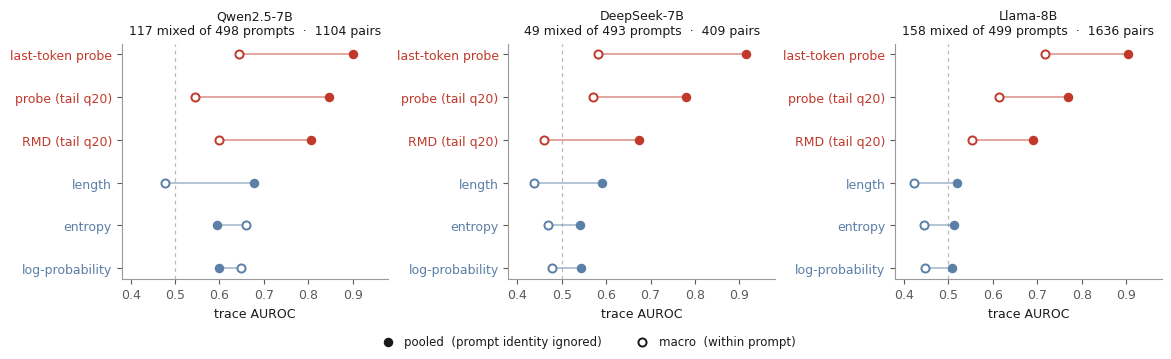

In [4]:
SCORES = [
    ("last_token_probe", "last-token probe", GEOMETRY),
    ("probe_hidden_tail_q20", "probe (tail q20)", GEOMETRY),
    ("rmd_tail_q20", "RMD (tail q20)", GEOMETRY),
    ("length", "length", OUTPUT_SIDE),
    ("mean_entropy", "entropy", OUTPUT_SIDE),
    ("mean_logprob", "log-probability", OUTPUT_SIDE),
]

fig, axes = plt.subplots(1, 3, figsize=(11.6, 3.5), sharex=True, constrained_layout=True)
for ax, label in zip(axes, MODELS):
    pop = PROBE["models"][label]["populations"]["parseable"]
    ys = np.arange(len(SCORES))[::-1]
    for y, (key, name, colour) in zip(ys, SCORES):
        point = pop["scores"][key]["point"]
        pooled, macro = point["pooled_auroc"], point["macro_prompt_auroc"]
        ax.plot([macro, pooled], [y, y], color=colour, lw=1.4, alpha=.45,
                zorder=1, solid_capstyle="butt")
        ax.scatter([pooled], [y], s=34, color=colour, zorder=3)
        ax.scatter([macro], [y], s=34, facecolor=PAPER, edgecolor=colour,
                   linewidth=1.4, zorder=3)
    ax.axvline(0.5, color="#b9b9b9", lw=.9, ls=(0, (3, 3)), zorder=0)
    ax.set_yticks(ys, [name for _, name, _ in SCORES])
    for tick, (_, _, colour) in zip(ax.get_yticklabels(), SCORES):
        tick.set_color(colour)
    ax.set_xlim(0.38, 0.98)
    ax.set_xlabel("trace AUROC")
    counts = pop["scores"]["last_token_probe"]["point"]
    ax.set_title(f"{NICE[label]}\n{counts['n_mixed_prompts']} mixed of "
                 f"{pop['n_prompts']} prompts  ·  "
                 f"{counts['n_within_prompt_pairs']} pairs", fontsize=9, pad=7)
handles = [
    axes[0].scatter([], [], s=34, color=INK,
                    label="pooled  (prompt identity ignored)"),
    axes[0].scatter([], [], s=34, facecolor=PAPER, edgecolor=INK, linewidth=1.4,
                    label="macro  (within prompt)"),
]
fig.legend(handles=handles, loc="outside lower center", ncol=2, fontsize=8.5,
           handletextpad=.4, columnspacing=2.4)
plt.show()

**Figure 1. Pooled and macro within-prompt trace AUROC.** Filled markers show
pooled AUROC; hollow markers show macro AUROC across mixed-outcome prompts. Red
marks hidden-state scores and blue marks output-derived scores. The panel title
reports the number of mixed prompts and within-prompt correct-incorrect pairs.
DeepSeek has only 49 mixed prompts, which limits the precision of its macro
estimate. On Qwen, the last-token probe exceeds entropy by 0.306 pooled
(0.901 versus 0.595) but falls below entropy within prompt (0.644 versus 0.660).
Length also shows a substantial pooled-to-macro decrease, so the decrease is
not unique to hidden-state scores.

In [5]:
T3 = pd.DataFrame([
    {
        "model": NICE[label],
        "score": name,
        "family": "hidden state" if colour == GEOMETRY else "output side",
        "pooled": pop["scores"][key]["point"]["pooled_auroc"],
        "micro": pop["scores"][key]["point"]["micro_pair_auroc"],
        "macro": pop["scores"][key]["point"]["macro_prompt_auroc"],
        "pooled - macro": pop["scores"][key]["point"]["pooled_minus_macro"],
        "95% CI": "[{:+.4f}, {:+.4f}]".format(
            pop["scores"][key]["bootstrap"]["pooled_minus_macro"]["ci_low"],
            pop["scores"][key]["bootstrap"]["pooled_minus_macro"]["ci_high"]),
        "mixed prompts": pop["scores"][key]["point"]["n_mixed_prompts"],
        "pairs": pop["scores"][key]["point"]["n_within_prompt_pairs"],
    }
    for label in MODELS
    for pop in [PROBE["models"][label]["populations"]["parseable"]]
    for key, name, colour in SCORES
])
table(
    T3,
    "Table 3 · pooled, pair-weighted and prompt-weighted trace AUROC "
    "(population: parseable)",
    note=("Pooled AUROC includes traces from single-outcome prompts. Micro and "
          "macro AUROC use only mixed-outcome prompts, with pair and prompt "
          "weighting, respectively. The parseable population matches the "
          "probe's training rule and excludes direct discrimination of missing "
          "answers. The CI applies to pooled minus macro AUROC."),
    highlight=[row.score == "last-token probe" for row in T3.itertuples()],
    **{"pooled": "{:.4f}", "micro": "{:.4f}", "macro": "{:.4f}",
       "pooled - macro": "{:+.4f}"},
)

# Continuity: the reference scores here must reproduce the frozen
# prompt_decomposition report, or "same traces" is not true.
FROZEN = {"mean_entropy": (0.571, 0.559, 0.599, 0.595),
          "mean_logprob": (0.575, 0.559, 0.595, 0.589),
          "length": (0.737, 0.563, 0.581, 0.582),
          "rmd_tail_q20": (0.839, 0.640, 0.658, 0.653)}
here = PROBE["models"]["qwen"]["populations"]["all_traces"]["scores"]
print("Validation against the frozen Qwen layer-21 report (population: all_traces)")
print(f"{'score':<16s} {'frozen':>28s}    {'here':>32s}")
for key, expected in FROZEN.items():
    point = here[key]["point"]
    got = (point["pooled_auroc"], point["prompt_centered_auroc"],
           point["macro_prompt_auroc"], point["micro_pair_auroc"])
    assert all(abs(a - b) < 1e-3 for a, b in zip(expected, got)), (key, expected, got)
    print(f"{key:<16s} {' / '.join(f'{v:.3f}' for v in expected):>28s}"
          f"    {' / '.join(f'{v:.4f}' for v in got):>32s}")
print("\nColumn order: pooled / prompt-centered / macro / micro. All values "
      "match within 0.001.\nThe prompt-centered statistic detects monotone "
      "transform changes that rank-based\nstatistics cannot detect. The "
      "validated length definition is -log1p(token count).")

from collections import Counter

LAYERS = pd.DataFrame([
    {"model": NICE[label],
     "layers offered": " / ".join(str(v) for v in PROBE["models"][label]["layers"]),
     "chosen, by fold": " · ".join(
         f"L{layer}×{count}" for layer, count in sorted(
             Counter(fold["selected_layer"] for fold in pop["folds"]).items())),
     "penalty C, by fold": " · ".join(
         f"{penalty:g}×{count}" for penalty, count in sorted(
             Counter(fold["selected_C"] for fold in pop["folds"]).items()))}
    for label in MODELS
    for pop in [PROBE["models"][label]["populations"]["parseable"]]
])
table(
    LAYERS,
    "Table 4 · in-fold layer and penalty selection, counted over the five "
    "outer folds",
    note=("Qwen selects the earliest offered layer in four of five folds, "
          "DeepSeek usually selects layer 14, and DeepSeek-Llama selects its "
          "middle layer in every fold. This variation does not support a common "
          "layer-localization claim. Layer and penalty are selected together "
          "inside each training split by prompt-disjoint inner CV."),
)

model,score,family,pooled,micro,macro,pooled - macro,95% CI,mixed prompts,pairs
Qwen2.5-7B,last-token probe,hidden state,0.9013,0.6214,0.6444,+0.2569,"[+0.1980, +0.3148]",117,1104
Qwen2.5-7B,probe (tail q20),hidden state,0.8474,0.5371,0.5460,+0.3014,"[+0.2306, +0.3656]",117,1104
Qwen2.5-7B,RMD (tail q20),hidden state,0.8069,0.5697,0.5984,+0.2085,"[+0.1441, +0.2693]",117,1104
Qwen2.5-7B,length,output side,0.6775,0.4534,0.4776,+0.1999,"[+0.1330, +0.2674]",117,1104
Qwen2.5-7B,entropy,output side,0.5951,0.6676,0.6602,-0.0651,"[-0.1383, +0.0033]",117,1104
Qwen2.5-7B,log-probability,output side,0.5983,0.6540,0.6494,-0.0511,"[-0.1250, +0.0179]",117,1104
DeepSeek-7B,last-token probe,hidden state,0.9139,0.6015,0.5823,+0.3316,"[+0.2260, +0.4499]",49,409
DeepSeek-7B,probe (tail q20),hidden state,0.7807,0.5501,0.5714,+0.2094,"[+0.1118, +0.3106]",49,409
DeepSeek-7B,RMD (tail q20),hidden state,0.6748,0.4621,0.4610,+0.2139,"[+0.1091, +0.3171]",49,409
DeepSeek-7B,length,output side,0.5916,0.4364,0.4365,+0.1551,"[+0.0418, +0.2730]",49,409


Validation against the frozen Qwen layer-21 report (population: all_traces)
score                                  frozen                                here
mean_entropy     0.571 / 0.559 / 0.599 / 0.595    0.5708 / 0.5588 / 0.5992 / 0.5948
mean_logprob     0.575 / 0.559 / 0.595 / 0.589    0.5747 / 0.5594 / 0.5947 / 0.5892
length           0.737 / 0.563 / 0.581 / 0.582    0.7367 / 0.5629 / 0.5807 / 0.5820
rmd_tail_q20     0.839 / 0.640 / 0.658 / 0.653    0.8393 / 0.6396 / 0.6584 / 0.6527

Column order: pooled / prompt-centered / macro / micro. All values match within 0.001.
The prompt-centered statistic detects monotone transform changes that rank-based
statistics cannot detect. The validated length definition is -log1p(token count).


model,layers offered,"chosen, by fold","penalty C, by fold"
Qwen2.5-7B,7 / 14 / 21,L7×4 · L21×1,0.003×5
DeepSeek-7B,7 / 14 / 21,L14×4 · L21×1,0.001×4 · 0.003×1
Llama-8B,8 / 16 / 24,L16×5,0.001×4 · 0.003×1


## 4. Experiment 3: test the prompt-level RMD increment

**Question.** Does RMD improve selective prediction after accounting for
information already available from the target model's eight outputs?

**Design.** For each prompt, `B0` uses aggregate trace length, token entropy,
token log-probability, and vote agreement among the eight sibling answers.
`B1` adds `rmd_tail_q20`, the mean RMD over the final 20% of tokens. Both
logistic readouts use the same prompt-disjoint folds and produce OOF reliability
scores. We compare their AURC on the primary `full_population` and three
secondary populations.

**Result.** On all 500 prompts, `B1 - B0` equals -0.0520 for Qwen, -0.0284 for
DeepSeek-Qwen, and -0.0469 for DeepSeek-Llama. All three fixed-pipeline 95% CIs
exclude zero.

**Interpretation.** RMD adds prompt-level ranking information beyond the four
output-derived features under this fixed fitting path. This experiment does not
claim that RMD verifies individual sibling traces or explains why a prompt is
difficult.

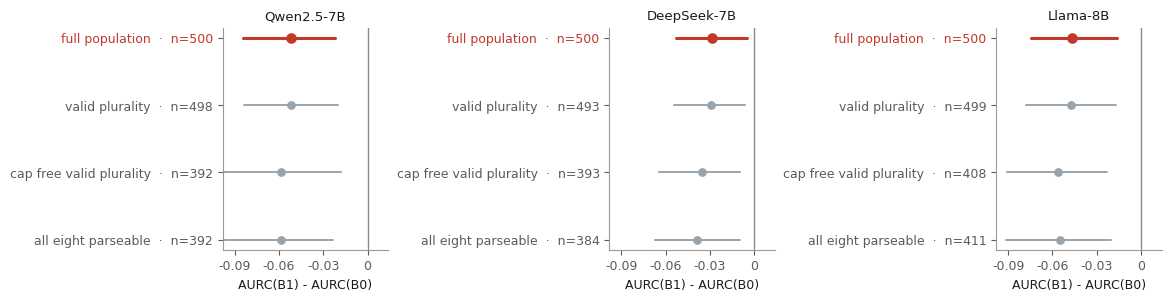

In [6]:
BY = {(row["model"], row["population"]): row for row in BUDGET["populations"]}
fig, axes = plt.subplots(1, 3, figsize=(11.6, 2.9), sharex=True, constrained_layout=True)
for ax, label in zip(axes, MODELS):
    ys = np.arange(len(ORDER))[::-1]
    for y, population in zip(ys, ORDER):
        row = BY[(label, population)]
        primary = population == PRIMARY
        colour = B1_COLOR if primary else "#9aa4ad"
        ax.plot([row["delta_ci_low"], row["delta_ci_high"]], [y, y],
                color=colour, lw=2.2 if primary else 1.4, solid_capstyle="round")
        ax.scatter([row["delta_estimate"]], [y], s=44 if primary else 28,
                   color=colour, zorder=3)
    ax.axvline(0, color="#8a8a8a", lw=1.0)
    # The prompt count rides on the tick label; as a separate annotation it
    # collides with either the zero rule or the tick text itself.
    ax.set_yticks(ys, [f"{population.replace('_', ' ')}  ·  "
                       f"n={BY[(label, population)]['n_prompts']}"
                       for population in ORDER])
    ax.get_yticklabels()[0].set_color(B1_COLOR)
    ax.set_xlabel("AURC(B1) - AURC(B0)")
    ax.set_title(NICE[label], fontsize=9.5, pad=6)
    ax.set_xlim(-0.098, 0.014)
    ax.set_xticks([-0.09, -0.06, -0.03, 0.0], ["-0.09", "-0.06", "-0.03", "0"])
plt.show()

**Figure 2. AURC difference between `B1` and `B0`.** Negative values favour
`B1`. Red markers denote the primary `full_population`; grey markers denote
secondary populations. All twelve intervals exclude zero. The cap-free
population gives a larger effect than the full population for each checkpoint,
showing that population filtering changes the estimated magnitude.

### Operational interpretation: accuracy after abstention

**Question.** How much accuracy does the ranking gain at specific operating
points?

**Design.** Each readout ranks all 500 prompts. At an abstention rate of 20%,
the system answers the highest-ranked 80% and defers the rest. The figure uses
the primary `full_population`. `B0` and `B1` are OOF readouts; entropy and
length are single-feature references. Bands show pointwise prompt-bootstrap
95% CIs for `B0` and `B1` with the fitted pipeline held fixed.

**Interpretation.** The AURC increment corresponds to higher accuracy among
answered prompts across the displayed operating range. The plot gives an
operational reading of the integrated result; it does not select a deployment
threshold.

### Answer-distribution control

**Question.** Does RMD add information beyond the complete distribution of the
eight sibling answers, rather than only beyond plurality agreement?

**Design.** `H` is minus the Shannon entropy of the exact-answer histogram over
parseable siblings. We compare `B0 + H` with and without `rmd_tail_q20` on all
500 prompts.

**Result.** Answer-distribution entropy changes AURC by at most 0.0016, while
RMD added to `B0 + H` improves AURC by 0.0281 to 0.0519 across the three
checkpoints. Each RMD interval excludes zero.

**Interpretation.** The RMD increment is not explained by answer-distribution
shape omitted from `vote_agreement`. At eight samples, `H` is close to the vote
feature already present in `B0`.

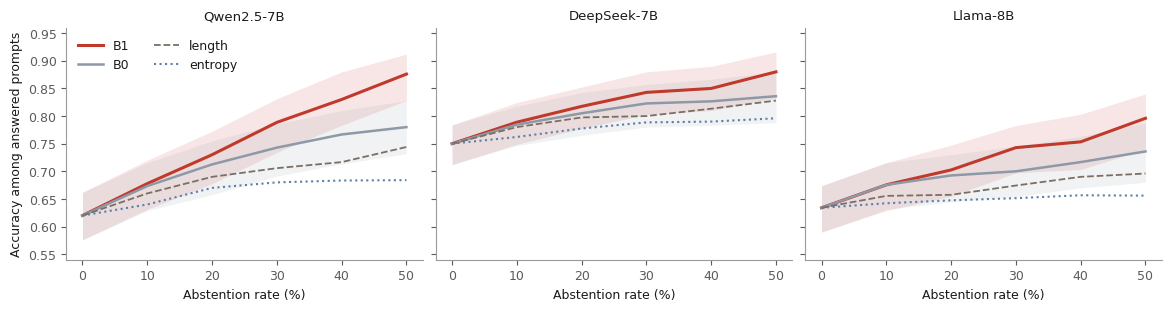

model,H over B0,RMD over B0 + H,"corr(H, vote)"
Qwen2.5-7B,"-0.0003 [-0.0016, +0.0009]","-0.0519 [-0.0829, -0.0216]",0.980
DeepSeek-7B,"+0.0001 [-0.0017, +0.0013]","-0.0281 [-0.0524, -0.0057]",0.967
Llama-8B,"+0.0016 [-0.0000, +0.0035]","-0.0462 [-0.0773, -0.0157]",0.984


In [7]:
OPERATING = BUDGET["operational_curves"]
fig, axes = plt.subplots(1, 3, figsize=(11.6, 3.0), sharex=True,
                         sharey=True, constrained_layout=True)
styles = {
    "B1": (B1_COLOR, "-", 2.2),
    "B0": (B0_COLOR, "-", 1.8),
    "length": ("#7a6f64", "--", 1.3),
    "entropy": (OUTPUT_SIDE, ":", 1.5),
}
for ax, label in zip(axes, MODELS):
    methods = OPERATING[label]["methods"]
    for name in ("B1", "B0", "length", "entropy"):
        curve = methods[name]
        x = 100 * np.asarray(curve["abstention_rates"])
        y = np.asarray(curve["accuracy"])
        colour, linestyle, width = styles[name]
        ax.plot(x, y, color=colour, ls=linestyle, lw=width, label=name)
        if name in {"B0", "B1"}:
            ax.fill_between(x, curve["ci_low"], curve["ci_high"],
                            color=colour, alpha=0.12, linewidth=0)
    ax.set_title(NICE[label])
    ax.set_xlabel("Abstention rate (%)")
    ax.set_xticks([0, 10, 20, 30, 40, 50])
    ax.set_ylim(0.54, 0.96)
axes[0].set_ylabel("Accuracy among answered prompts")
axes[0].legend(loc="upper left", ncol=2)
plt.show()

H_ROWS = []
fmt_delta = lambda entry: (
    f"{entry['point_estimate']:+.4f} "
    f"[{entry['ci_low']:+.4f}, {entry['ci_high']:+.4f}]"
)
for model in CLOSEST["models"]:
    pop = model["populations"][PRIMARY]
    deltas = pop["paired_deltas_aurc"]
    H_ROWS.append({
        "model": NICE[model["label"]],
        "H over B0": fmt_delta(deltas["H_over_B0"]),
        "RMD over B0 + H": fmt_delta(deltas["rmd_tail_over_B0_plus_H"]),
        "corr(H, vote)": pop["redundancy"]
            ["neg_answer_entropy_vs_vote_agreement"]["pearson"],
    })
table(
    pd.DataFrame(H_ROWS),
    "Table 5 &middot; RMD after adding exact-answer-distribution entropy",
    note=("AURC on <code>full_population</code>; lower is better. "
          "<code>H</code> adds little to <code>B0</code>, while the RMD "
          "increment remains below zero on all three checkpoints. The last "
          "column shows why: answer entropy and plurality agreement contain "
          "nearly the same ordering at eight samples."),
    **{"corr(H, vote)": "{:.3f}"},
)

### 4a. Experiment 4: compare whole-trace and tail RMD

**Question.** Does the final-20% restriction provide a consistent improvement
over the published whole-trace ATRMD score?

**Design.** We compare two prompt-level features on `full_population`:

| Region | Score |
|:--|:--|
| all generated tokens | `rmd_full`, the published ATRMD feature |
| the final 20% of tokens | `rmd_tail_q20`, the feature `B1` uses |

**Result.** ATRMD accounts for nearly all of the RMD increment on both
reasoning-distilled checkpoints, and the tail adds no detectable improvement.
For Qwen, ATRMD does not improve over `B0`, while the tail restriction does.
The two features have Pearson correlation 0.931 to 0.957.

**Interpretation.** The prompt-level RMD increment replicates across the three
checkpoints, but its token-region localization does not. The final-20%
restriction is a Qwen-specific refinement in this sample, not a new general
method. Pre-registered stop rule `1b` therefore closes further region and
percentile sweeps. Notebook
[11](11_prompt_geometry_core_experiments.ipynb) retains the older exploratory
comparison with an entropy-selected region.

In [8]:
def interval(entry):
    return (f"{entry['point_estimate']:+.4f} "
            f"[{entry['ci_low']:+.4f}, {entry['ci_high']:+.4f}]")


# Table 6 is on the same scale and population as sections 2-4: risk against
# coverage, lower is better, C_B over all 500 prompts.
L = pd.DataFrame([
    {
        "model": NICE[m["label"]],
        "layer": m["layer"],
        "B1 - B0": interval(P["paired_deltas_aurc"]["B1_minus_B0"]),
        "ATRMD over B0": interval(P["paired_deltas_aurc"]["rmd_full_over_B0"]),
        "tail over ATRMD": interval(P["paired_deltas_aurc"]["rmd_tail_over_rmd_full"]),
        "corr(ATRMD, tail)": P["redundancy"]["rmd_full_vs_rmd_tail_q20"]["pearson"],
    }
    for m in CLOSEST["models"]
    for P in [m["populations"][PRIMARY]]
])
_clears = lambda d: d["ci_high"] < 0
table(
    L, "Table 6 &middot; tail RMD compared with published whole-trace ATRMD, "
       f"{PRIMARY}",
    note=("Lower AURC is better; a negative delta favours the feature named on "
          "the left. <code>rmd_full</code> is the published ATRMD feature. ATRMD "
          "has a CI below zero relative to <code>B0</code> on "
          + ", ".join(NICE[m["label"]] for m in CLOSEST["models"]
                      if _clears(m["populations"][PRIMARY]["paired_deltas_aurc"]
                                 ["rmd_full_over_B0"]))
          + ", but not on "
          + ", ".join(NICE[m["label"]] for m in CLOSEST["models"]
                      if not _clears(m["populations"][PRIMARY]["paired_deltas_aurc"]
                                     ["rmd_full_over_B0"]))
          + ". Tail RMD has a CI below zero relative to ATRMD on "
          + ", ".join(NICE[m["label"]] for m in CLOSEST["models"]
                      if _clears(m["populations"][PRIMARY]["paired_deltas_aurc"]
                                 ["rmd_tail_over_rmd_full"]))
          + " only. The high correlations show that the features remain closely "
          "related despite the model-dependent contrast.<br><br>"
          "Stop rule <code>1a</code> also remains open: tail RMD relative to "
          "<code>B0 + answer-distribution entropy</code> has a CI below zero on "
          f"{sum(_clears(m['populations'][PRIMARY]['paired_deltas_aurc']['rmd_tail_over_B0_plus_H']) for m in CLOSEST['models'])}"
          " of 3 checkpoints; the rule would reject the claim after two failures."),
    **{"corr(ATRMD, tail)": "{:.2f}"},
)

model,layer,B1 - B0,ATRMD over B0,tail over ATRMD,"corr(ATRMD, tail)"
Qwen2.5-7B,21,"-0.0520 [-0.0832, -0.0218]","-0.0178 [-0.0435, +0.0105]","-0.0464 [-0.0724, -0.0224]",0.93
DeepSeek-7B,21,"-0.0284 [-0.0531, -0.0060]","-0.0287 [-0.0534, -0.0055]","-0.0030 [-0.0109, +0.0035]",0.96
Llama-8B,24,"-0.0469 [-0.0773, -0.0178]","-0.0445 [-0.0739, -0.0151]","-0.0041 [-0.0118, +0.0035]",0.94


### 4b. Experiment 5: refit the complete analysis pipeline

**Question.** Do the main conclusions retain their sign when new prompt
partitions change the fitted references, selected hyperparameters, and readout
coefficients?

**Design.** The registered sweep repeats the complete fitting procedure for
four partition seeds. In contrast, the CIs reported above resample prompts
while holding the seed-42 folds, selected layer, and fitted coefficients fixed.

**Result.** Pending. The canonical result file is accepted only after all
registered seeds, checkpoints, and quantities are complete.

**Interpretation.** The fixed-pipeline intervals quantify sampling variation
among prompts under one fitted pipeline. They do not quantify variation caused
by fitting the pipeline on a different prompt partition. Publication of the
confirmatory claims depends on this registered stability check.

In [9]:
if REFIT is None:
    display(HTML(
        f"<div style='background:#fdf6e3;border-left:3px solid #c9a227;"
        f"padding:11px 15px;font:400 12px/1.6 {SANS};color:{INK};max-width:780px'>"
        "<b>Gate open: full-refit stability is registered and pending.</b><br>"
        "Registered in <code>EXPERIMENT_LOG.md</code> (2026-08-22, "
        "<i>Refit stability, registered before the sweep runs</i>). The decision "
        "rule demotes a quantity if its sign changes across refits. If the sign "
        "remains stable, the paper reports the across-refit spread and replaces "
        "the fixed-pipeline interval when that spread is materially wider."
        "<br><br>Until the complete canonical result exists, all reported CIs "
        "remain conditional on one fitted partition."
        "</div>"))
else:
    G = pd.DataFrame([
        {
            "model": NICE[label],
            "quantity": name.replace("_", " "),
            "refits": summary["n"],
            "mean": summary.get("mean"),
            "min": summary.get("min"),
            "max": summary.get("max"),
            "spread": summary.get("spread"),
            "sign stable": "yes" if summary.get("sign_stable") else "NO",
            "drift from seed 42": summary.get("max_abs_drift_from_frozen"),
        }
        for label in MODELS
        for name in ("b1_minus_b0_aurc", "probe_pooled_minus_macro",
                     "peer_residual_deployable_aurc")
        for summary in [REFIT["summary"][label][name]]
        if summary.get("n")
    ])
    table(
        G, f"Table 7 · full-refit stability over seeds {REFIT['seeds']}",
        note=("Each seed changes the prompt partition and refits the full "
              "pipeline: reference distributions, OOF scores, prompt-level "
              "readouts, probe layer and penalty selection, and peer-model "
              "comparisons. Interpret sign stability using the decision rule "
              "registered before the sweep."),
        **{"mean": "{:+.4f}", "min": "{:+.4f}", "max": "{:+.4f}",
           "spread": "{:.4f}", "drift from seed 42": "{:.4f}"},
    )

## 5. Experiment 6: compare RMD with peer-model agreement

**Question.** How does RMD compare with reliability information obtained by
sampling a second model, after making the generation cost explicit?

**Design.** A deployable **agreement score** is the fraction of peer traces
whose answer matches the target model's plurality answer. It does not use the
gold answer. The ladder adds 1, 2, 4, or 8 generations from either peer, or from
both peers, to `B0`. A separate **graded peer score** measures the fraction of
peer traces that match the gold answer. This score is an oracle diagnostic and
cannot be computed at deployment. `B1` uses the target model's stored hidden
states and requires zero additional generations, although hidden-state storage
and scoring still have computational cost.

**Result.** At one additional peer generation, the six target-peer comparisons
produce four ties, one RMD win, and one peer win after Holm correction. Across
all 36 correlated and unadjusted ladder contrasts, the descriptive counts are
16 peer wins, 16 ties, and 4 RMD wins.

**Interpretation.** Peer agreement is a competitive baseline, but its value
depends more on the target-peer pair than on the number of peer samples in this
range. No peer rung exactly matches the cost of `B1`; the supported operational
advantage of RMD is zero additional generations, not uniform superiority.

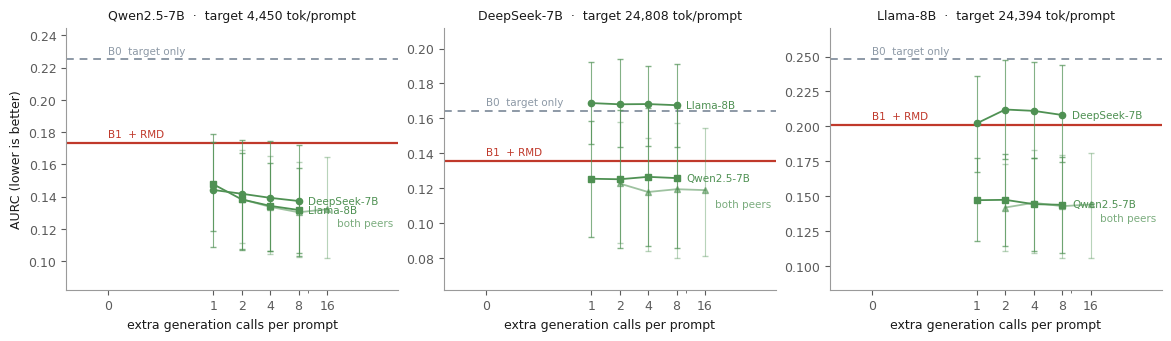

In [10]:
LADDER_BY = {m["label"]: m for m in LADDER["models"]}
SIZES = LADDER["ladder_sizes"]

fig, axes = plt.subplots(1, 3, figsize=(11.6, 3.3), sharey=False,
                         constrained_layout=True)
for ax, label in zip(axes, MODELS):
    entry = LADDER_BY[label]
    rungs = entry["populations"][PRIMARY]["rungs"]
    ax.axhline(rungs["B0"]["aurc_mean"], color=B0_COLOR, lw=1.4,
               ls=(0, (4, 3)), zorder=1)
    ax.axhline(rungs["B1"]["aurc_mean"], color=B1_COLOR, lw=1.6, zorder=1)
    ax.annotate("B0  target only", (0, rungs["B0"]["aurc_mean"]),
                xytext=(0, 4), textcoords="offset points", fontsize=7.5,
                color=B0_COLOR, ha="left")
    ax.annotate("B1  + RMD", (0, rungs["B1"]["aurc_mean"]),
                xytext=(0, 4), textcoords="offset points", fontsize=7.5,
                color=B1_COLOR, ha="left")
    for peer, marker in zip(entry["peers"] + ["both"], ["o", "s", "^"]):
        xs, ys, err_low, err_high = [], [], [], []
        for size in SIZES:
            name = f"B0_agree_{peer}_m{size}"
            rung = rungs.get(name)
            if rung is None:
                continue
            delta = entry["populations"][PRIMARY]["contrasts"][f"B1_minus_{name}"]["aurc"]
            xs.append(rung["cost"]["extra_calls"])
            ys.append(rung["aurc_mean"])
            err_low.append(delta["ci_high"] - delta["point_estimate"])
            err_high.append(delta["point_estimate"] - delta["ci_low"])
        faded = peer == "both"
        ax.plot(xs, ys, marker=marker, ms=4.5, lw=1.3, color=PEER_COLOR,
                alpha=.55 if faded else 1.0, zorder=2)
        ax.errorbar(xs, ys, yerr=[err_low, err_high], fmt="none",
                    color=PEER_COLOR, capsize=2, lw=.8,
                    alpha=.4 if faded else .7, zorder=1)
        # The combined rung ends one tick further right and often lands on top
        # of the single-peer label, so it is dropped a line.
        ax.annotate(NICE.get(peer, "both peers"), (xs[-1], ys[-1]),
                    xytext=(7, -10 if faded else 0), textcoords="offset points",
                    va="center", fontsize=7.5, color=PEER_COLOR,
                    alpha=.75 if faded else 1.0)
    ax.set_xscale("symlog", linthresh=1)
    ax.set_xticks([0, 1, 2, 4, 8, 16], ["0", "1", "2", "4", "8", "16"])
    ax.set_xlim(-0.4, 90)
    ax.set_xlabel("extra generation calls per prompt")
    ax.set_title(f"{NICE[label]}  ·  target {entry['target_tokens_per_prompt']:,.0f} "
                 f"tok/prompt", fontsize=9, pad=6)
    ax.margins(y=0.16)
axes[0].set_ylabel("AURC (lower is better)")
plt.show()

**Figure 3. Cost ladder for deployable peer agreement.** The horizontal axis
shows additional peer generations per prompt; the vertical axis shows AURC.
The red horizontal line is `B1`, and the grey dashed line is `B0`. Each green
series adds an agreement score from one peer or both peers. Vertical bars show
paired 95% CIs for the AURC difference relative to `B1`; an interval that
crosses the red line does not distinguish the peer rung from `B1`.

The target-peer pair determines most of the observed variation. Qwen peer
agreement improves over `B1` for the DeepSeek-Llama target at each sampled
budget. DeepSeek-Llama peer agreement performs worse than `B1` for the
DeepSeek-Qwen target. Increasing the peer budget from one to eight generations
changes these contrasts little.

In [11]:
VERDICT = LADDER["cheapest_peer_verdict"]
WORDS = {"B1": "RMD wins", "peer": "peer wins", "tie": "tie"}


def verdict(delta):
    """The ladder's own rule, applied to a contrast: an interval spanning zero
    is a tie, whatever the point estimate does."""
    low, high = delta["ci_low"], delta["ci_high"]
    if low < 0 < high:
        return "tie"
    return "peer wins" if delta["point_estimate"] > 0 else "RMD wins"


LADDER_TALLY = {}
for label in MODELS:
    fp = LADDER_BY[label]["populations"][PRIMARY]
    for name in fp["rungs"]:
        if not name.startswith("B0_agree_"):
            continue
        outcome = verdict(fp["contrasts"][f"B1_minus_{name}"]["aurc"])
        LADDER_TALLY[outcome] = LADDER_TALLY.get(outcome, 0) + 1
print("Descriptive results for all deployable rungs on the primary population "
      f"({sum(LADDER_TALLY.values())} rungs: 3 targets x 3 peer sets x "
      f"{len(SIZES)} sizes)")
for outcome, count in sorted(LADDER_TALLY.items(), key=lambda kv: -kv[1]):
    print(f"  {outcome:<12s} {count:>3}")
print("  All four RMD wins are DeepSeek-7B against Llama-8B peers, at every "
      "rung size.\n")
PRIMARY_PEER_P = {
    f"{label}:{name}": LADDER_BY[label]["populations"][PRIMARY]
        ["contrasts"][f"B1_minus_{name}"]["aurc"]["p_two_sided"]
    for label in MODELS
    for name, rung in VERDICT[label]["rungs"].items()
    if rung["kind"] == "agree"
}
PRIMARY_PEER_HOLM = holm_correction(PRIMARY_PEER_P)
rows = []
for label in MODELS:
    for name, rung in VERDICT[label]["rungs"].items():
        if rung["kind"] != "agree":
            continue
        key = f"{label}:{name}"
        delta = LADDER_BY[label]["populations"][PRIMARY]["contrasts"][f"B1_minus_{name}"]["aurc"]
        rows.append({
            "target": NICE[label],
            "peer (1 extra generation)": name.replace("B0_agree_", "").replace("_m1", ""),
            "AURC(B1) - AURC(rung)": rung["aurc_delta_B1_minus_rung"],
            "95% CI": f"[{rung['ci'][0]:+.4f}, {rung['ci'][1]:+.4f}]",
            "p raw": delta["p_two_sided"],
            "p Holm": PRIMARY_PEER_HOLM[key],
            "verdict": WORDS[rung["winner"]],
        })
T6 = pd.DataFrame(rows)
counts = T6["verdict"].value_counts()
table(
    T6,
    "Table 8 · the deployable comparison at one extra generation",
    note=(f"{counts.get('tie', 0)} ties, {counts.get('RMD wins', 0)} RMD win, "
          f"{counts.get('peer wins', 0)} peer win over {len(T6)} target-peer "
          "pairs. Negative values favour <code>B1</code>. The six one-generation "
          "comparisons form the primary peer family, and the table reports Holm-"
          "corrected p-values for that family."),
    highlight=[verdict != "tie" for verdict in T6["verdict"]],
    **{"AURC(B1) - AURC(rung)": "{:+.4f}", "p raw": "{:.3f}", "p Holm": "{:.3f}"},
)

T7 = pd.DataFrame([
    {
        "target": NICE[label],
        "graded peer (1 extra generation)": name.replace("B0_graded_", "").replace("_m1", ""),
        "AURC(B1) - AURC(rung)": rung["aurc_delta_B1_minus_rung"],
        "95% CI": f"[{rung['ci'][0]:+.4f}, {rung['ci'][1]:+.4f}]",
        "deployable": "no; uses gold answer",
    }
    for label in MODELS
    for name, rung in VERDICT[label]["rungs"].items()
    if rung["kind"] == "graded"
])
table(
    T7,
    "Table 9 · diagnostic only: the gold-aware graded peer",
    note=("The graded score compares peer answers with the gold answer and is "
          "therefore unavailable at deployment. It is an oracle diagnostic, not "
          "a deployable baseline. Conclusions based on this table cannot be "
          "transferred to the agreement score in Table 8."),
    **{"AURC(B1) - AURC(rung)": "{:+.4f}"},
)

Descriptive results for all deployable rungs on the primary population (36 rungs: 3 targets x 3 peer sets x 4 sizes)
  tie           16
  peer wins     16
  RMD wins       4
  All four RMD wins are DeepSeek-7B against Llama-8B peers, at every rung size.



target,peer (1 extra generation),AURC(B1) - AURC(rung),95% CI,p raw,p Holm,verdict
Qwen2.5-7B,deepseek,+0.0250,"[-0.0099, +0.0603]",0.170,0.510,tie
Qwen2.5-7B,deepseek_llama,+0.0250,"[-0.0014, +0.0540]",0.062,0.248,tie
DeepSeek-7B,deepseek_llama,-0.0341,"[-0.0576, -0.0108]",0.008,0.040,RMD wins
DeepSeek-7B,qwen,+0.0129,"[-0.0201, +0.0464]",0.408,0.816,tie
Llama-8B,deepseek,+0.0014,"[-0.0327, +0.0366]",0.878,0.878,tie
Llama-8B,qwen,+0.0544,"[+0.0240, +0.0838]",0.000,0.000,peer wins


target,graded peer (1 extra generation),AURC(B1) - AURC(rung),95% CI,deployable
Qwen2.5-7B,deepseek,+0.0520,"[+0.0271, +0.0828]",no; uses gold answer
Qwen2.5-7B,deepseek_llama,+0.0238,"[-0.0034, +0.0514]",no; uses gold answer
DeepSeek-7B,deepseek_llama,+0.0625,"[+0.0384, +0.0888]",no; uses gold answer
DeepSeek-7B,qwen,+0.0589,"[+0.0253, +0.0920]",no; uses gold answer
Llama-8B,deepseek,+0.0207,"[-0.0190, +0.0575]",no; uses gold answer
Llama-8B,qwen,+0.0049,"[-0.0314, +0.0448]",no; uses gold answer


## 6. Supported claim, withdrawn statements, and limitations

### Supported claim

Under a fixed eight-sample MATH-500 protocol, adding a hidden-state RMD feature
to target-model output features improves prompt-level selective prediction on
three checkpoints. The feature uses hidden states from the existing traces and
requires no additional generations. The current CIs condition on one fitted
pipeline; the registered full-refit sweep must confirm sign stability.

The evidence supports the RMD increment, not a new RMD method or a general tail
localization. Whole-trace ATRMD provides nearly the complete increment on the
two reasoning-distilled checkpoints, while the final-20% restriction is needed
for Qwen in this evaluation. Pooled hidden-state AUROC also overstates
within-prompt trace discrimination. Peer agreement remains a competitive
baseline with an additional generation cost.

### Withdrawn statements

The following statements appeared in an earlier version and conflict with the
current evidence:

| Withdrawn claim | Why |
|:--|:--|
| the score is read from *a single forward pass* | RMD uses retained states from eight generated traces; it requires no additional generations but still requires generation and hidden-state processing |
| capped rows are *censored observations, not failures* | a missing answer is an observed failure for correctness at the stated budget; it is censored only for eventual correctness beyond that budget |
| peer pass rates *absorb roughly four fifths* of the increment | this result used the gold-aware graded peer score, which is unavailable at deployment |
| *most of the increment is prompt difficulty* | the deployable agreement comparison does not reproduce this mechanism interpretation |
| peer models are only a non-deployable control | agreement scores are deployable; graded peer scores remain diagnostic |
| *tail localization is what replicates* | whole-trace ATRMD provides the increment on both reasoning-distilled checkpoints; the tail is required only for Qwen in this evaluation |

### Limitations and falsification tests

- The full-refit sweep is the main open gate. Until it completes, every CI in
  this notebook is conditional on one prompt partition and fitting path.
- The evaluation covers one dataset, one generation budget per checkpoint, and
  three checkpoints from two architecture families.
- Only one checkpoint is not reasoning-distilled. The localization split cannot
  establish an effect of distillation.
- The within-prompt analyses use 117, 49, and 158 mixed prompts. A dataset with
  more mixed outcomes could produce a smaller pooled-to-macro gap.
- The probe searches three layers selected from an earlier Qwen layer study.
  That study found two depth regions with stronger signal, near layers 6-10 and
  20-26, but this pattern has not been tested on the two distilled checkpoints.
- **Reranking sibling answers** is unsupported at this budget. Only 39 of 500
  prompts had tied plurality answers, and about 10 ties contained both a correct
  and an incorrect option; all 15 tested tie-breakers were null.
- **Allocating additional samples** is unsupported. Single-trace RMD predicts
  prompt difficulty, but the registered allocation precheck found that it did
  not predict the marginal benefit of sampling more traces.
- A hidden-state readout that retains strong macro within-prompt AUROC would
  falsify the conclusion for that readout. The present experiments do not rule
  out such a method.

### Provenance

- Experiment ledger, protocol and every correction: [`EXPERIMENT_LOG.md`](../EXPERIMENT_LOG.md)
- Paper strategy: [`PAPER_STRATEGY_RMD.md`](../PAPER_STRATEGY_RMD.md)
- Budget-indexed outcomes: [`results/budget_outcomes/`](../results/budget_outcomes/README.md)
- Peer cost ladder: [`results/peer_cost_ladder/`](../results/peer_cost_ladder/README.md)
- Closest baselines, stop rules 1a and 1b: [`results/closest_baselines/`](../results/closest_baselines/README.md)
- Last-token probe: [`results/last_token_probe/`](../results/last_token_probe/README.md)
- Refit stability (registered; canonical result pending): `controls/refit_stability.py`
- Every closure artifact, loaded: [notebook 17](17_rmd_experiment_ledger.ipynb)
- Long-form abstention detail: [notebook 12](12_wave1_abstention.ipynb)
- DeepConf null and label efficiency: [notebook 13](13_deepconf_null_and_label_efficiency.ipynb)